# Tarea M33-AD – Jorge Alejandro Carballido Shimidzu

Exploratory Data Analysis (EDA) sobre ventas de videojuegos

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 2. Lectura del archivo

In [3]:
df = pd.read_csv("/Users/mariapreciado/Downloads/vgsales.csv")

## 3. Exploración inicial

In [4]:
df.head()
df.tail()
df.sample(5)
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


## 4. Limpieza y validación

In [5]:
cols_numericas = ["Year", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df["Year"] = df["Year"].astype(int)

## Totales

In [6]:
total_juegos = df.shape[0]
total_generos = df["Genre"].nunique()
total_plataformas = df["Platform"].nunique()

print("Total videojuegos:", total_juegos)
print("Total géneros:", total_generos)
print("Total plataformas:", total_plataformas)

Total videojuegos: 16291
Total géneros: 12
Total plataformas: 31


## Ventas por año

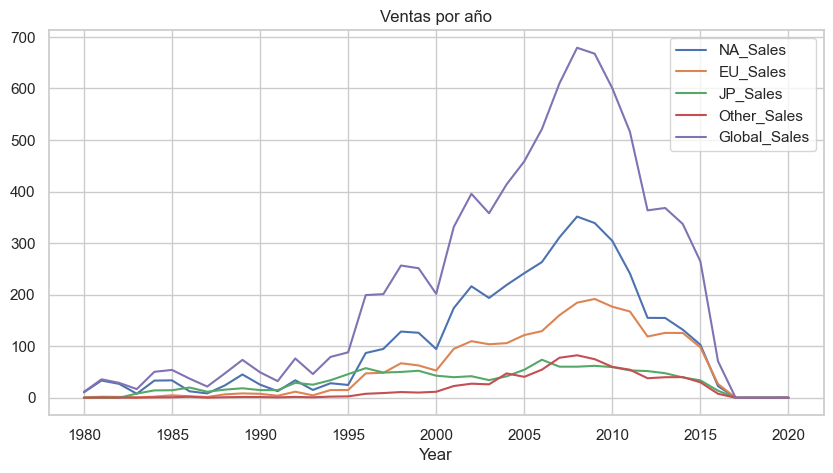

In [7]:
ventas_anuales = df.groupby("Year")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales","Global_Sales"]].sum()
ventas_anuales.plot(figsize=(10,5))
plt.title("Ventas por año")
plt.show()

## Juegos más vendidos por año

In [8]:
top_juegos = df.loc[df.groupby("Year")["Global_Sales"].idxmax()]
top_juegos[["Year", "Name", "Global_Sales"]].head()

,Year,Name,Global_Sales
258,1980,Asteroids,4.31
239,1981,Pitfall!,4.50
89,1982,Pac-Man,7.81
421,1983,Baseball,3.20
9,1984,Duck Hunt,28.31


## Plataformas con más ingresos por año

In [9]:
top_plataformas = df.groupby(["Year","Platform"])["Global_Sales"].sum().reset_index()
top_plataformas = top_plataformas.loc[top_plataformas.groupby("Year")["Global_Sales"].idxmax()]
top_plataformas.head()

,Year,Platform,Global_Sales
0,1980,2600,11.38
1,1981,2600,35.77
2,1982,2600,28.86
4,1983,NES,10.96
6,1984,NES,50.09


## Comparación de ventas por género

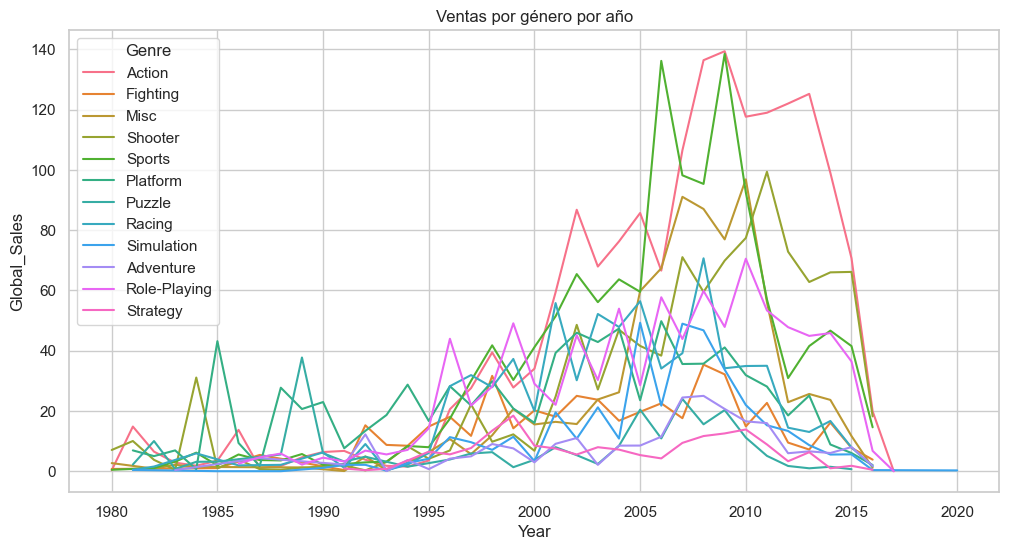

In [10]:
ventas_genero = df.groupby(["Year","Genre"])["Global_Sales"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=ventas_genero, x="Year", y="Global_Sales", hue="Genre")
plt.title("Ventas por género por año")
plt.show()

## Insights adicionales

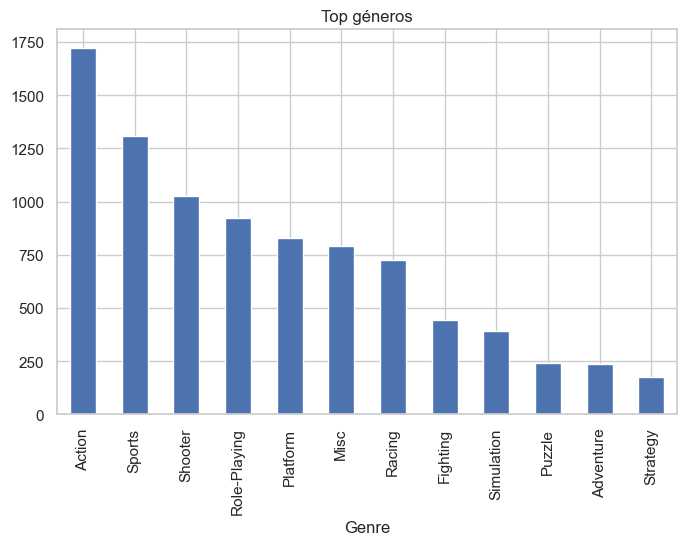

In [11]:
top_generos = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
top_generos.plot(kind="bar", figsize=(8,5))
plt.title("Top géneros")
plt.show()

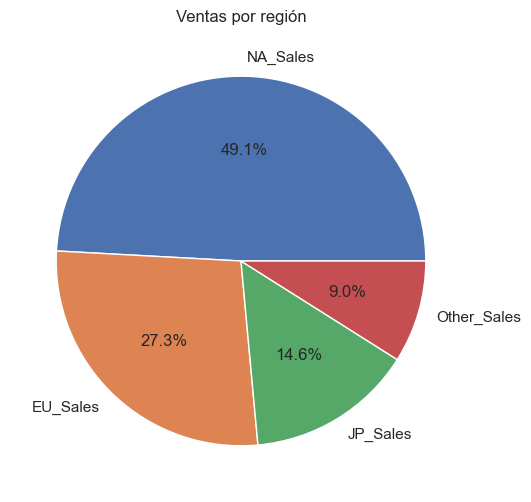

In [12]:
region_sales = df[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()
region_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Ventas por región")
plt.show()

## Últimos 4 años

In [13]:
ultimo_anio = df["Year"].max()
df_ultimos = df[df["Year"] >= ultimo_anio - 3]

## Crecimiento

In [14]:
crecimiento_genero = df_ultimos.groupby(["Year","Genre"])["Global_Sales"].sum().unstack()
crecimiento_pct = crecimiento_genero.pct_change().mean().sort_values()

print("Mayor crecimiento género:", crecimiento_pct.idxmax())
print("Menor crecimiento género:", crecimiento_pct.idxmin())

Mayor crecimiento género: Action
Menor crecimiento género: Action


/var/folders/9k/t2r1bbsx1qs5hwv059k6j8qm0000gn/T/ipykernel_4972/1944887477.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crecimiento_pct = crecimiento_genero.pct_change().mean().sort_values()


In [15]:
crecimiento_plataforma = df_ultimos.groupby(["Year","Platform"])["Global_Sales"].sum().unstack()
crecimiento_pct_plat = crecimiento_plataforma.pct_change().mean().sort_values()

print("Mayor crecimiento plataforma:", crecimiento_pct_plat.idxmax())
print("Menor crecimiento plataforma:", crecimiento_pct_plat.idxmin())

Mayor crecimiento plataforma: PS4
Menor crecimiento plataforma: PS4


/var/folders/9k/t2r1bbsx1qs5hwv059k6j8qm0000gn/T/ipykernel_4972/748195140.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crecimiento_pct_plat = crecimiento_plataforma.pct_change().mean().sort_values()


In [16]:
crecimiento_juego = df_ultimos.groupby(["Year","Name"])["Global_Sales"].sum().unstack()
crecimiento_pct_juego = crecimiento_juego.pct_change().mean().sort_values()

print("Mayor crecimiento juego:", crecimiento_pct_juego.idxmax())
print("Menor crecimiento juego:", crecimiento_pct_juego.idxmin())

Mayor crecimiento juego: Brothers Conflict: Precious Baby
Menor crecimiento juego: Brothers Conflict: Precious Baby


/var/folders/9k/t2r1bbsx1qs5hwv059k6j8qm0000gn/T/ipykernel_4972/313152362.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crecimiento_pct_juego = crecimiento_juego.pct_change().mean().sort_values()


## Oportunidades de mercado

In [17]:
ventas_genero = df.groupby("Genre")["Global_Sales"].sum()
conteo_genero = df["Genre"].value_counts()

ratio = (ventas_genero / conteo_genero).sort_values(ascending=False)
ratio.head()

Genre
Platform        0.947577
Shooter         0.800468
Role-Playing    0.628456
Racing          0.593273
Sports          0.568247
dtype: float64

In [18]:
df_ultimos.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)

Platform
DS     0.29
PS4    0.03
PSV    0.02
Name: Global_Sales, dtype: float64